In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import KBinsDiscretizer

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_train=pd.read_csv('/content/drive/MyDrive/train_Insurance.csv')
df_test=pd.read_csv('/content/drive/MyDrive/test_Insurance.csv')

In [4]:
df_train.head()

,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,NumberOfWindows,Geo_Code,Claim
0,H13501,2012,1.0,1,N,V,V,U,1240.0,Wood-framed,without,75117,non
1,H14962,2012,1.0,0,N,V,V,U,900.0,Non-combustible,without,62916,non
2,H17755,2013,1.0,1,V,N,O,R,4984.0,Non-combustible,4,31149,oui
3,H13369,2016,0.5,0,N,V,V,U,600.0,Wood-framed,without,6012,oui
4,H12988,2012,1.0,0,N,V,V,U,900.0,Non-combustible,without,57631,non


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         5012 non-null   object 
 1   YearOfObservation   5012 non-null   int64  
 2   Insured_Period      5012 non-null   float64
 3   Residential         5012 non-null   int64  
 4   Building_Painted    5012 non-null   object 
 5   Building_Fenced     5012 non-null   object 
 6   Garden              5008 non-null   object 
 7   Settlement          5012 non-null   object 
 8   Building Dimension  4935 non-null   float64
 9   Building_Type       5012 non-null   object 
 10  NumberOfWindows     5012 non-null   object 
 11  Geo_Code            4939 non-null   object 
 12  Claim               5012 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 509.2+ KB


In [6]:
df_train.describe()

,YearOfObservation,Insured_Period,Residential,Building Dimension
count,5012.000000,5012.000000,5012.000000,4935.000000
mean,2013.660215,0.869713,0.301077,1876.898683
std,1.383134,0.219496,0.458772,2267.277397
min,2012.000000,0.500000,0.000000,1.000000
25%,2012.000000,0.500000,0.000000,520.000000
50%,2013.000000,1.000000,0.000000,1067.000000
75%,2015.000000,1.000000,1.000000,2280.000000
max,2016.000000,1.000000,1.000000,20840.000000


In [7]:
df_train['Geo_Code'] = pd.to_numeric(df_train['Geo_Code'],errors='coerce')
print("*Type après conversion* :", df_train['Geo_Code'].dtype)

*Type après conversion* : float64


In [8]:
df_train.describe(include="number")

,YearOfObservation,Insured_Period,Residential,Building Dimension,Geo_Code
count,5012.000000,5012.000000,5012.000000,4935.000000,4901.000000
mean,2013.660215,0.869713,0.301077,1876.898683,50938.324832
std,1.383134,0.219496,0.458772,2267.277397,29809.146750
min,2012.000000,0.500000,0.000000,1.000000,1053.000000
25%,2012.000000,0.500000,0.000000,520.000000,21231.000000
50%,2013.000000,1.000000,0.000000,1067.000000,57663.000000
75%,2015.000000,1.000000,1.000000,2280.000000,75118.000000
max,2016.000000,1.000000,1.000000,20840.000000,95607.000000


In [9]:
df_train.describe(include="object")

,Customer Id,Building_Painted,Building_Fenced,Garden,Settlement,Building_Type,NumberOfWindows,Claim
count,5012,5012,5012,5008,5012,5012,5012,5012
unique,5012,2,2,2,2,4,11,2
top,H13501,V,N,O,R,Non-combustible,without,non
freq,1,3763,2535,2532,2537,2310,2476,3886


In [10]:
print("Nombre de valeurs Nulles pour chaque descripteur :")
df_train.isnull().sum()

Nombre de valeurs Nulles pour chaque descripteur :


Customer Id             0
YearOfObservation       0
Insured_Period          0
Residential             0
Building_Painted        0
Building_Fenced         0
Garden                  4
Settlement              0
Building Dimension     77
Building_Type           0
NumberOfWindows         0
Geo_Code              111
Claim                   0
dtype: int64

In [11]:
print("Nombre Totale de valeurs Nulles  :")
df_train.isnull().sum().sum()

Nombre Totale de valeurs Nulles  :


192

In [12]:
duplicates=df_train[df_train.duplicated()]
Sum_duplicates=duplicates.sum()
print("Somme des linges dupliquées: ",Sum_duplicates.sum())

Somme des linges dupliquées:  0.0


In [13]:

df_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

arr = df_imputer.fit_transform(df_train[['Garden']])

df_train['Garden'] = arr[:, 0]

df_train.head()

,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,NumberOfWindows,Geo_Code,Claim
0,H13501,2012,1.0,1,N,V,V,U,1240.0,Wood-framed,without,75117.0,non
1,H14962,2012,1.0,0,N,V,V,U,900.0,Non-combustible,without,62916.0,non
2,H17755,2013,1.0,1,V,N,O,R,4984.0,Non-combustible,4,31149.0,oui
3,H13369,2016,0.5,0,N,V,V,U,600.0,Wood-framed,without,6012.0,oui
4,H12988,2012,1.0,0,N,V,V,U,900.0,Non-combustible,without,57631.0,non


In [14]:
df1_imputer=SimpleImputer(missing_values=np.nan,strategy='median')
arr1=df1_imputer.fit_transform(df_train.loc[:,['Geo_Code']])
df_train['Geo_Code']=arr1

In [15]:
df2_imputer=SimpleImputer(missing_values=np.nan,strategy='median')
arr2=df_imputer.fit_transform(df_train.loc[:,['Building Dimension']])
df_train['Building Dimension']=arr2

In [16]:
df_train.head()

,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,NumberOfWindows,Geo_Code,Claim
0,H13501,2012,1.0,1,N,V,V,U,1240.0,Wood-framed,without,75117.0,non
1,H14962,2012,1.0,0,N,V,V,U,900.0,Non-combustible,without,62916.0,non
2,H17755,2013,1.0,1,V,N,O,R,4984.0,Non-combustible,4,31149.0,oui
3,H13369,2016,0.5,0,N,V,V,U,600.0,Wood-framed,without,6012.0,oui
4,H12988,2012,1.0,0,N,V,V,U,900.0,Non-combustible,without,57631.0,non


In [17]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         5012 non-null   object 
 1   YearOfObservation   5012 non-null   int64  
 2   Insured_Period      5012 non-null   float64
 3   Residential         5012 non-null   int64  
 4   Building_Painted    5012 non-null   object 
 5   Building_Fenced     5012 non-null   object 
 6   Garden              5012 non-null   object 
 7   Settlement          5012 non-null   object 
 8   Building Dimension  5012 non-null   float64
 9   Building_Type       5012 non-null   object 
 10  NumberOfWindows     5012 non-null   object 
 11  Geo_Code            5012 non-null   float64
 12  Claim               5012 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 509.2+ KB


In [18]:
nbr_val_manquantes=df_train.isnull().sum().sum()
print("nombre Totale des valeurs manquantes de df_train :",nbr_val_manquantes)

nombre Totale des valeurs manquantes de df_train : 0


In [19]:
def outliers(df,col):
  Q1,Q3=np.percentile(df[col],[25,75])
  IQR=Q3-Q1
  upper_limit=Q3+1.5*IQR
  lower_limit=Q1-1.5*IQR
  df[col]=np.where(df[col]>=upper_limit,upper_limit, np.where(df[col]<=lower_limit,lower_limit,df[col]))

In [20]:
L_Num=list(df_train.select_dtypes(include="number"))
L_Num

['YearOfObservation',
 'Insured_Period',
 'Residential',
 'Building Dimension',
 'Geo_Code']

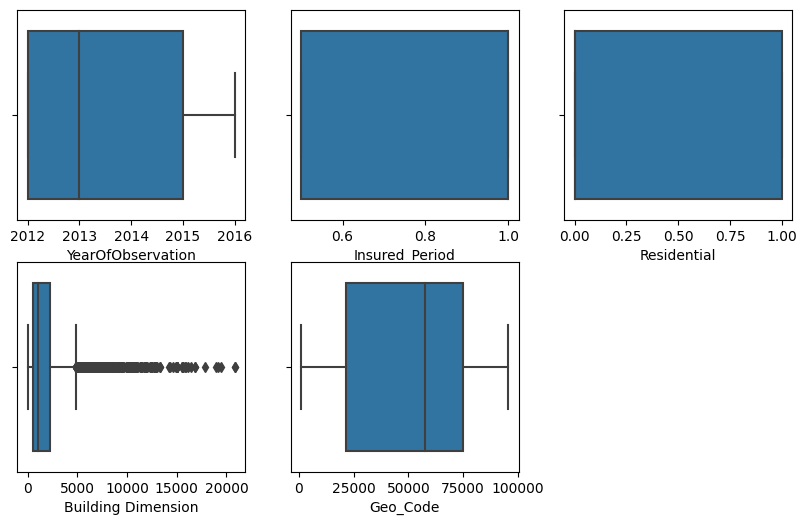

In [21]:
fig=plt.figure(figsize=(10,6))
for i in range(len(L_Num)):
  plt.subplot(2,3,i+1)
  sns.boxplot(data=df_train,x=L_Num[i])
plt.show()

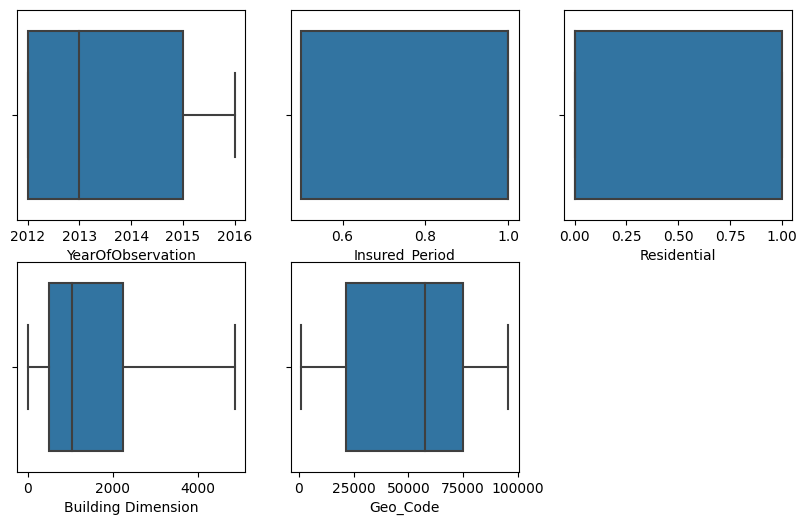

In [22]:
for i in range(4):
  outliers(df_train,L_Num[i])
fig=plt.figure(figsize=(10,6))
for i in range(len(L_Num)):
  plt.subplot(2,3,i+1)
  sns.boxplot(data=df_train,x=L_Num[i])
plt.show()

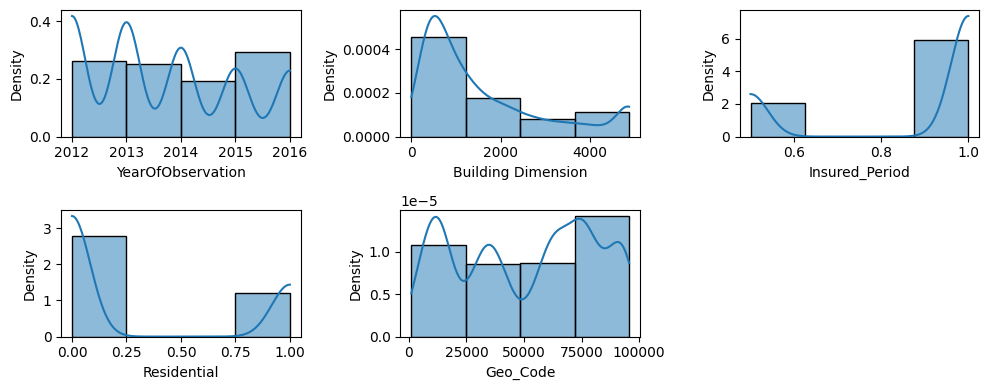

In [23]:
from scipy.stats import gaussian_kde

f=plt.figure(figsize=(10,4))
plt.subplot(2,3,1)
sns.histplot(x="YearOfObservation", data=df_train, bins=4,kde=True, stat='density')
plt.subplot(2,3,2)
sns.histplot(x="Building Dimension", data=df_train, bins=4,kde=True, stat='density')
plt.subplot(2,3,3)
sns.histplot(x="Insured_Period", data=df_train, bins=4,kde=True, stat='density')
plt.subplot(2,3,4)
sns.histplot(x="Residential", data=df_train, bins=4,kde=True, stat='density')
plt.subplot(2,3,5)
sns.histplot(x="Geo_Code", data=df_train, bins=4,kde=True, stat='density')
plt.tight_layout()
plt.show()

In [24]:
L_Dis=['Customer Id','Building_Painted','Building_Fenced','Garden','Settlement','Building_Type','NumberOfWindows']
L_Dis

['Customer Id',
 'Building_Painted',
 'Building_Fenced',
 'Garden',
 'Settlement',
 'Building_Type',
 'NumberOfWindows']

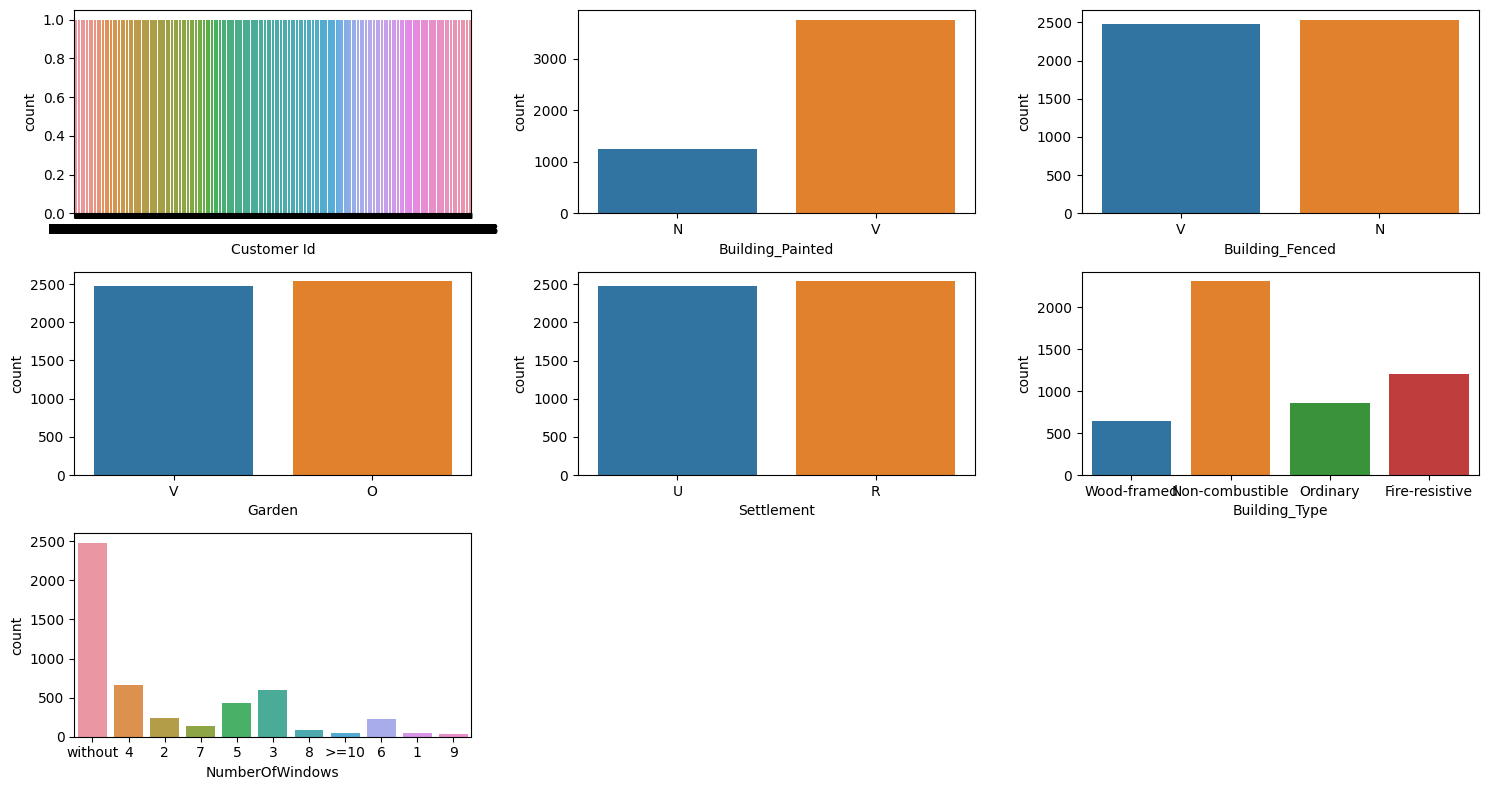

In [25]:
fig=plt.figure(figsize=(15,8))
for i in range(len(L_Dis)):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df_train,x=L_Dis[i])
plt.tight_layout()
plt.show()

In [26]:
df_train.drop(labels=['Customer Id'],axis=1,inplace=True)
df_train.head()

,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,NumberOfWindows,Geo_Code,Claim
0,2012.0,1.0,1.0,N,V,V,U,1240.0,Wood-framed,without,75117.0,non
1,2012.0,1.0,0.0,N,V,V,U,900.0,Non-combustible,without,62916.0,non
2,2013.0,1.0,1.0,V,N,O,R,4875.0,Non-combustible,4,31149.0,oui
3,2016.0,0.5,0.0,N,V,V,U,600.0,Wood-framed,without,6012.0,oui
4,2012.0,1.0,0.0,N,V,V,U,900.0,Non-combustible,without,57631.0,non


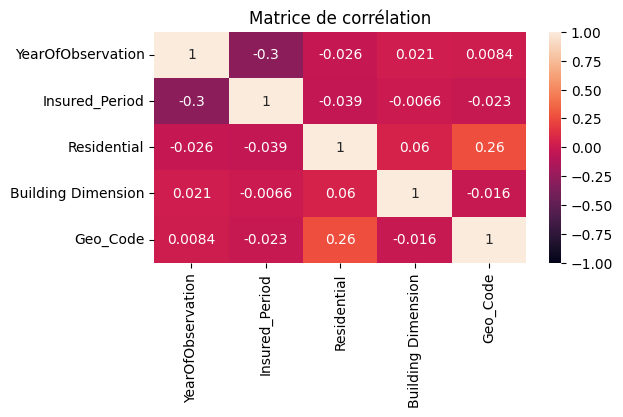

In [27]:
plt.figure(figsize=(6,3))
df_train_corr=df_train.corr(numeric_only=True)
sns.heatmap(df_train_corr,annot=True,vmin=-1,vmax=1)
plt.title('Matrice de corrélation')
plt.show()

In [28]:
#label encoder
def label_encoder(df,col):
  enc=LabelEncoder()
  df[col]=enc.fit_transform(df.loc[:,col])

In [29]:
L_dis= ['Building_Painted', 'Building_Fenced','Garden', 'Settlement']

In [30]:
for i in L_dis:
    label_encoder(df_train,i)
df_train.head()

,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,NumberOfWindows,Geo_Code,Claim
0,2012.0,1.0,1.0,0,1,1,1,1240.0,Wood-framed,without,75117.0,non
1,2012.0,1.0,0.0,0,1,1,1,900.0,Non-combustible,without,62916.0,non
2,2013.0,1.0,1.0,1,0,0,0,4875.0,Non-combustible,4,31149.0,oui
3,2016.0,0.5,0.0,0,1,1,1,600.0,Wood-framed,without,6012.0,oui
4,2012.0,1.0,0.0,0,1,1,1,900.0,Non-combustible,without,57631.0,non


In [31]:
#ordinalEncoder
enc = OrdinalEncoder()
df_train[["Building_Type"]]=enc.fit_transform(df_train.loc[:,["Building_Type"]])
df_train[["NumberOfWindows"]]=enc.fit_transform(df_train.loc[:,["NumberOfWindows"]])
df_train

,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,NumberOfWindows,Geo_Code,Claim
0,2012.0,1.0,1.0,0,1,1,1,1240.0,3.0,10.0,75117.0,non
1,2012.0,1.0,0.0,0,1,1,1,900.0,1.0,10.0,62916.0,non
2,2013.0,1.0,1.0,1,0,0,0,4875.0,1.0,3.0,31149.0,oui
3,2016.0,0.5,0.0,0,1,1,1,600.0,3.0,10.0,6012.0,oui
4,2012.0,1.0,0.0,0,1,1,1,900.0,1.0,10.0,57631.0,non
...,...,...,...,...,...,...,...,...,...,...,...,...
5007,2013.0,1.0,0.0,0,1,1,1,550.0,2.0,10.0,33063.0,oui
5008,2012.0,0.5,0.0,1,0,0,0,1000.0,0.0,3.0,13004.0,non
5009,2015.0,1.0,1.0,1,0,0,0,480.0,2.0,2.0,94059.0,non
5010,2012.0,0.5,0.0,1,0,0,0,536.0,0.0,3.0,74243.0,non


*techniques d'apprentissage supervisé*

In [32]:
from sklearn.model_selection import train_test_split
X = df_train.iloc[:, :-1].values
Y = df_train.iloc[:, -1].values
print(type(X), X.shape)
print(type(Y), Y.shape)

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3, shuffle=False, random_state=1)

<class 'numpy.ndarray'> (5012, 11)
<class 'numpy.ndarray'> (5012,)


In [33]:
#DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

cls = DecisionTreeClassifier()
cls.fit(X_train, Y_train)
print(cls.classes_)
print(list(df_train))

['non' 'oui']
['YearOfObservation', 'Insured_Period', 'Residential', 'Building_Painted', 'Building_Fenced', 'Garden', 'Settlement', 'Building Dimension', 'Building_Type', 'NumberOfWindows', 'Geo_Code', 'Claim']


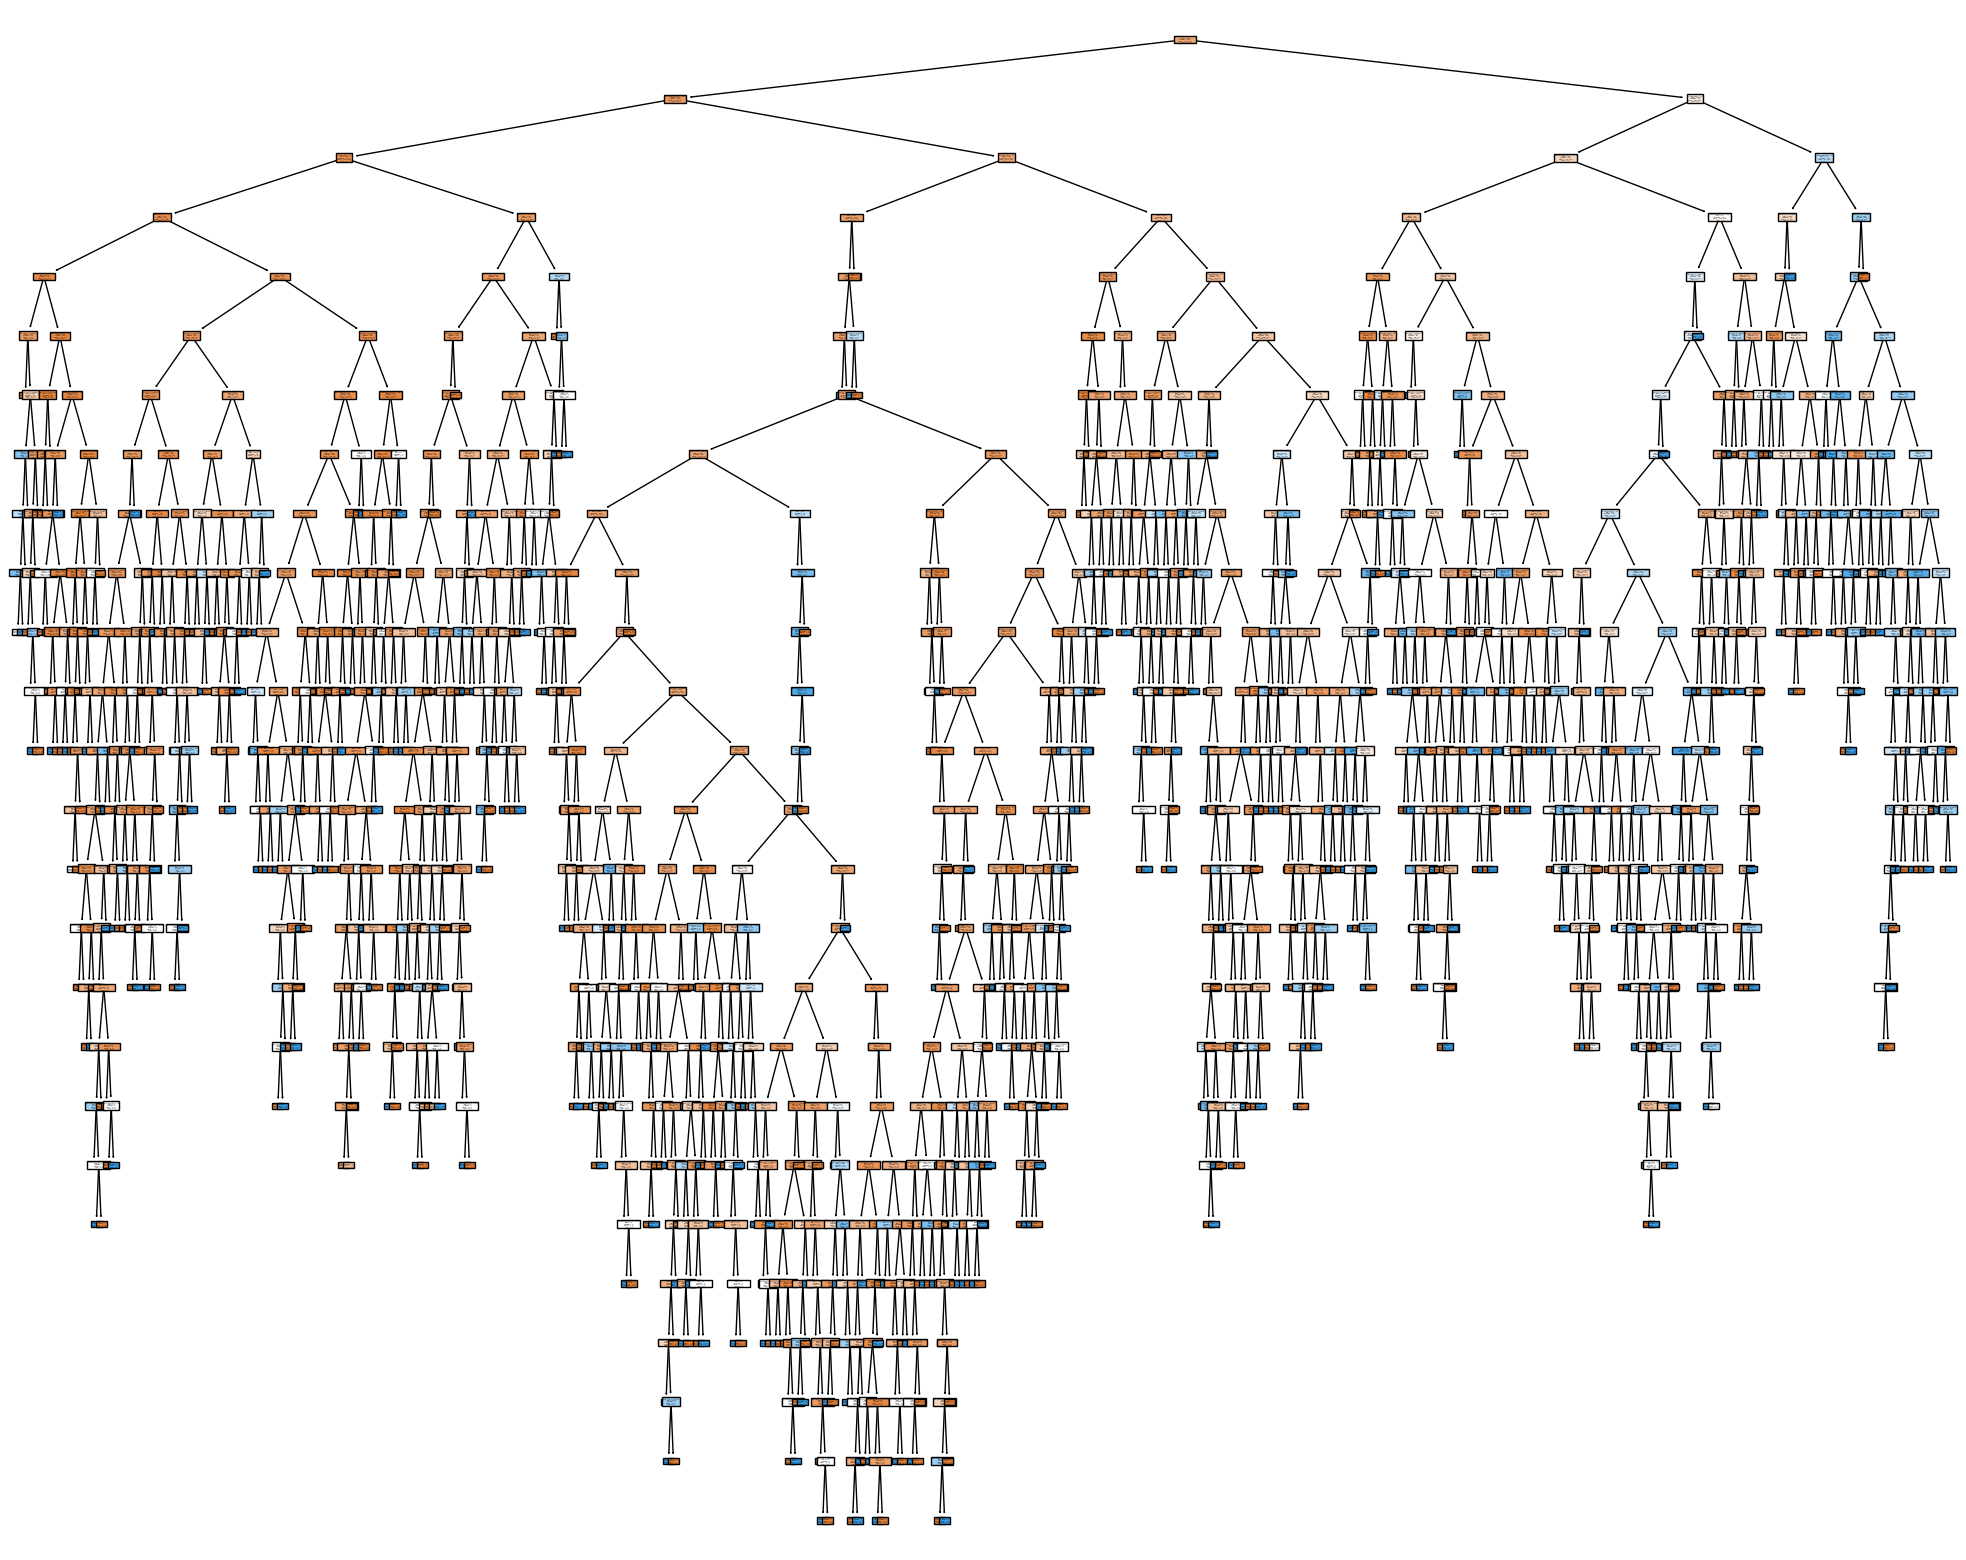

|--- Building Dimension <= 2728.00
|   |--- Building Dimension <= 797.50
|   |   |--- Building_Type <= 1.50
|   |   |   |--- Insured_Period <= 0.75
|   |   |   |   |--- YearOfObservation <= 2012.50
|   |   |   |   |   |--- Geo_Code <= 46864.50
|   |   |   |   |   |   |--- class: non
|   |   |   |   |   |--- Geo_Code >  46864.50
|   |   |   |   |   |   |--- Geo_Code <= 67494.00
|   |   |   |   |   |   |   |--- Building Dimension <= 490.50
|   |   |   |   |   |   |   |   |--- Building Dimension <= 467.00
|   |   |   |   |   |   |   |   |   |--- Building Dimension <= 410.00
|   |   |   |   |   |   |   |   |   |   |--- class: non
|   |   |   |   |   |   |   |   |   |--- Building Dimension >  410.00
|   |   |   |   |   |   |   |   |   |   |--- class: oui
|   |   |   |   |   |   |   |   |--- Building Dimension >  467.00
|   |   |   |   |   |   |   |   |   |--- class: non
|   |   |   |   |   |   |   |--- Building Dimension >  490.50
|   |   |   |   |   |   |   |   |--- class: oui
|   |   |   

In [34]:
fig=plt.figure(figsize=(25,20))
plot_tree(cls, feature_names=list(df_train)[:-1], class_names=list(cls.classes_), filled=True)
plt.show()
print(export_text(cls, feature_names=list(df_train)[:-1]))

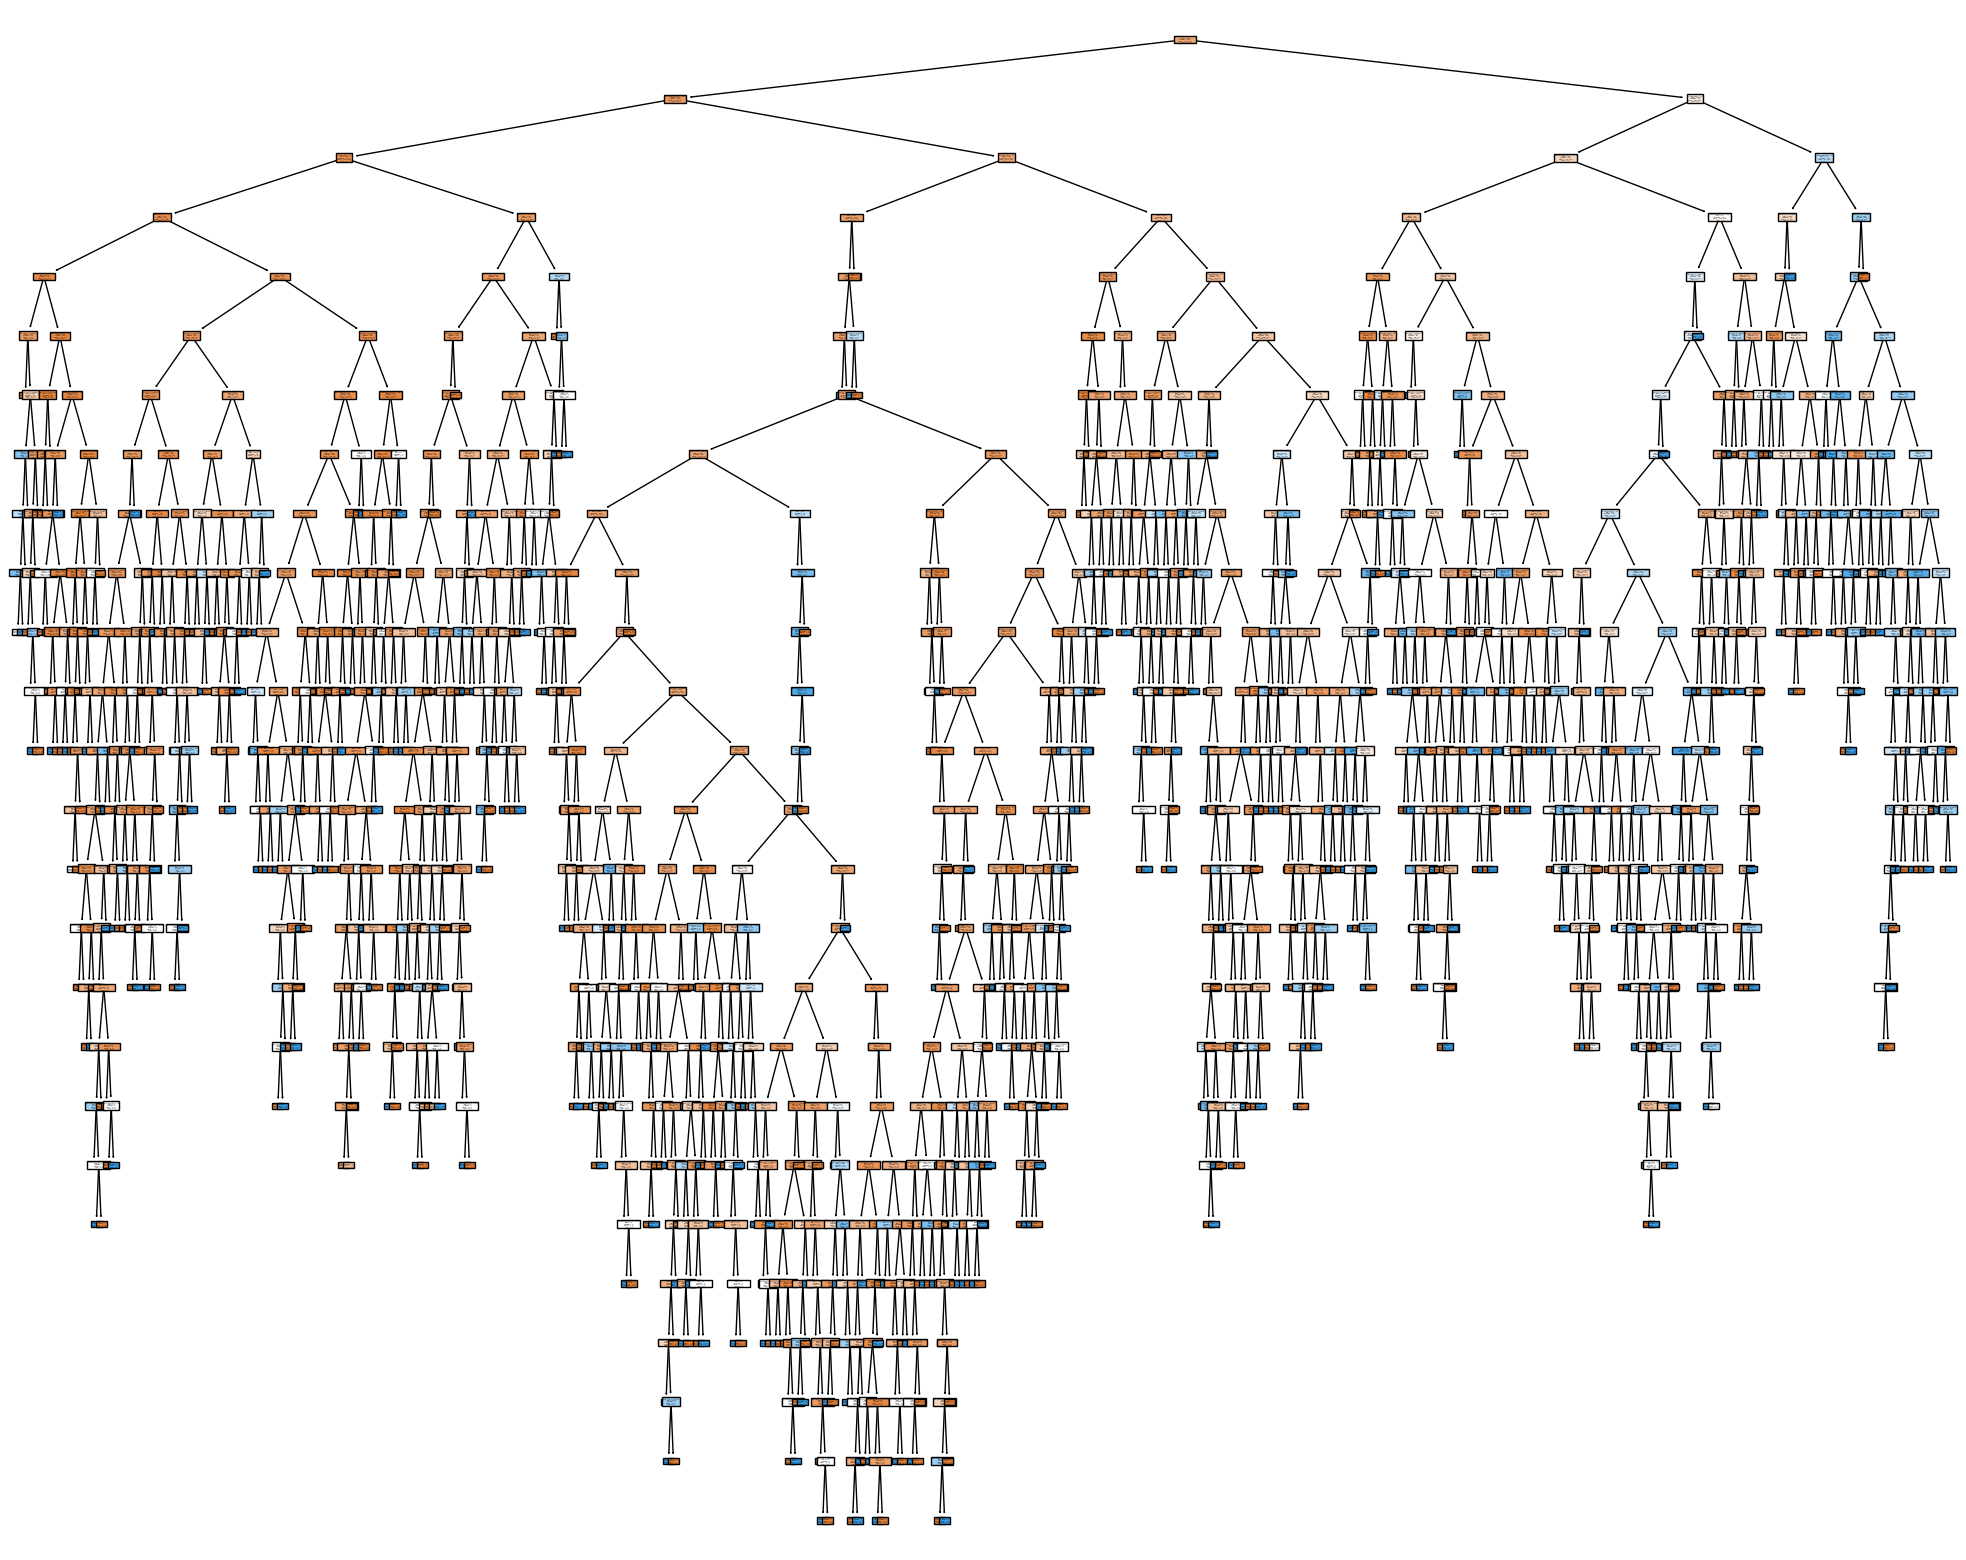

In [36]:
plt.figure(figsize=(25, 20))
plot_tree(cls, feature_names=list(df_train)[:-1], class_names=list(cls.classes_), filled=True)
plt.show()

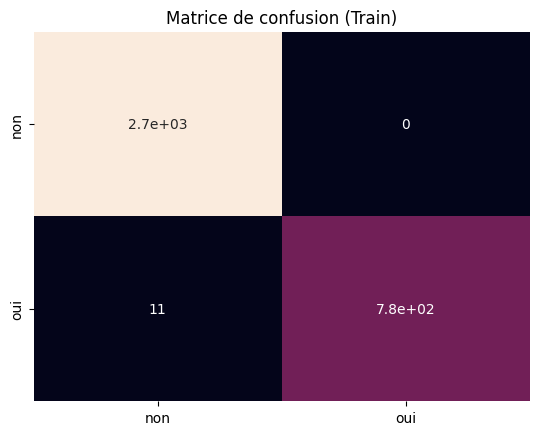

In [37]:
#Validation
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Validation sur les données d’apprentissage
Y_p_train=cls.predict(X_train)
c_m_train=confusion_matrix(Y_train, Y_p_train)
sns.heatmap(c_m_train, annot=True, cbar=False,xticklabels=cls.classes_, yticklabels=cls.classes_)
plt.title('Matrice de confusion (Train)')
plt.show()

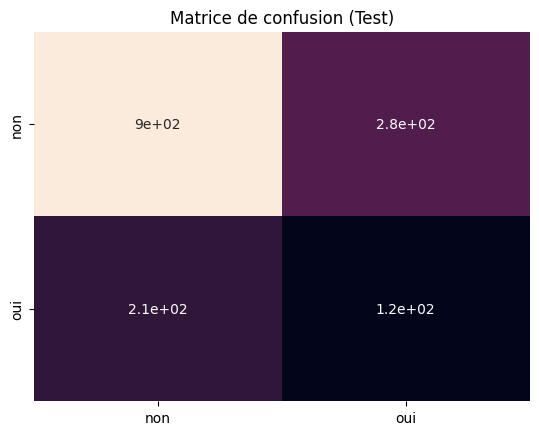

In [38]:
# Validation sur les données de test
Y_p_test=cls.predict(X_test)
c_m_train=confusion_matrix(Y_test, Y_p_test)
sns.heatmap(c_m_train, annot=True, cbar=False,xticklabels=cls.classes_, yticklabels=cls.classes_)
plt.title('Matrice de confusion (Test)')
plt.show()

In [39]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_train, Y_p_train))
print(accuracy_score(Y_test, Y_p_test))

0.9968643101482326
0.6722074468085106


In [40]:
#SVC
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
# Encoder la variable cible si elle est textuelle
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
# Créer et entraîner le modèle SVC
svc = SVC()
svc.fit(X_train, Y_train_encoded)
Y_train_pred = svc.predict(X_train)
# Afficher les classes et les caractéristiques
print("Classes:", label_encoder.classes_)
print("Caractéristiques:", list(df_train))
#RQue:SVC n'a pas une structure d'arbre comme DecisionTreeClassifier,donc il n'y a pas de fonction plot_tree pour SVC)

Classes: ['non' 'oui']
Caractéristiques: ['YearOfObservation', 'Insured_Period', 'Residential', 'Building_Painted', 'Building_Fenced', 'Garden', 'Settlement', 'Building Dimension', 'Building_Type', 'NumberOfWindows', 'Geo_Code', 'Claim']


In [47]:
#accuracy
Y_train_pred = svc.predict(X_train)
accuracy_train = accuracy_score(Y_train_encoded, Y_train_pred)
print(accuracy_train)

0.7730900798175598


In [43]:
#MLPClassifier
from sklearn.neural_network import MLPClassifier
# Encoder la variable cible si elle est textuelle
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
# Créer et entraîner le modèle MLPClassifier
mlp = MLPClassifier()
mlp.fit(X_train, Y_train_encoded)
# Afficher les classes et les caractéristiques
print("Classes:", label_encoder.classes_)
print("Caractéristiques:", list(df_train.columns))


Classes: ['non' 'oui']
Caractéristiques: ['YearOfObservation', 'Insured_Period', 'Residential', 'Building_Painted', 'Building_Fenced', 'Garden', 'Settlement', 'Building Dimension', 'Building_Type', 'NumberOfWindows', 'Geo_Code', 'Claim']


In [46]:
#accuracy
Y_train_pred = mlp.predict(X_train)
accuracy_train = accuracy_score(Y_train_encoded, Y_train_pred)
print(accuracy_train)

0.7782212086659065


In [45]:
#GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
# Encoder la variable cible si elle est textuelle
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
# Créer et entraîner le modèle GradientBoostingClassifier
gbc = GradientBoostingClassifier()
gbc.fit(X_train, Y_train_encoded)
# Afficher les classes et les caractéristiques
print("Classes:", label_encoder.classes_)
print("Caractéristiques:", list(df_train.columns))


Classes: ['non' 'oui']
Caractéristiques: ['YearOfObservation', 'Insured_Period', 'Residential', 'Building_Painted', 'Building_Fenced', 'Garden', 'Settlement', 'Building Dimension', 'Building_Type', 'NumberOfWindows', 'Geo_Code', 'Claim']


In [48]:
#accuracy
Y_train_pred = gbc.predict(X_train)
accuracy_train = accuracy_score(Y_train_encoded, Y_train_pred)
print(accuracy_train)

0.8110034207525656


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:583: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


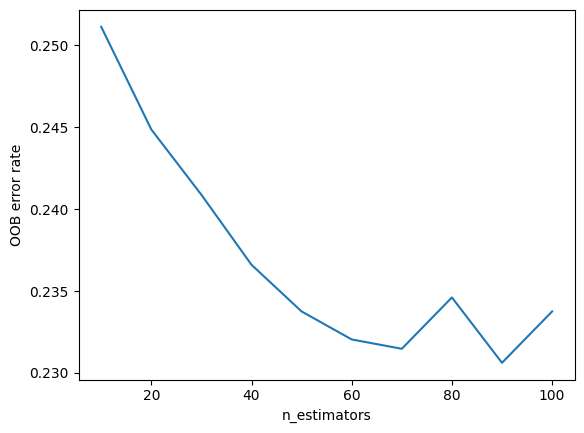

In [62]:
#RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rfc= RandomForestClassifier(n_estimators=100,criterion='gini', max_depth=None, min_samples_split=2,min_samples_leaf=1,max_features='sqrt',max_leaf_nodes=None,
bootstrap=True, oob_score=True, max_samples=0.63)
rfc.fit(X_train, Y_train)
# Prédire les classes sur l'ensemble de train
Y_train_pred = rfc.predict(X_train)

def oob_error(nbT, model=rfc):
  model.set_params(n_estimators=nbT)
  model.fit(X_train,Y_train)
  return 1-model.oob_score_


n_estimators=list(range(10,101,10))
oob_errors=list(map(oob_error,n_estimators))
plt.plot(n_estimators,oob_errors)
plt.xlabel("n_estimators")
plt.ylabel("OOB error rate")
plt.show()

In [63]:
#accuracy
Y_train_pred = rfc.predict(X_train)
# Calculer l'accuracy sur l'ensemble d'entraînement
accuracy_train = accuracy_score(Y_train, Y_train_pred)
print(accuracy_train)

0.9672177879133409
